# Ranking pages with weak CTR for their Google position

**Subject: CTR / Engagement Opportunity Scoring**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rimlazrek1/flyrank-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

Numbers below load from receipts in `work/outputs/` (charts live there too; `work/figures/` is a fallback). No warehouse pull is required to re-run this notebook.

---

## Abstract

Which pages should a reviewer open first when CTR looks weak for their Google position tier? Using Mar–Apr 2026 past features and a May 2026 proxy label from the FlyRank ML Internship dataset (~52k eligible pages, `imp_prev >= 500`), we compare a transparent past-`ctr_gap` rule to logistic regression under client GroupKFold. On the same eligible folds (base rate ≈ 51.3%), mean Precision@50 is 0.945 for the model versus 0.775 for the rule. The model also surfaces high-stake pages the fixed rule often ranks much lower. This is a decision-support review queue with action archetypes — not a claim that edits raise clicks, and not a prediction of Google’s algorithm.

## 1. Question

**Research question.** Which pages get shown in Google but attract fewer clicks than peers in the same position tier — and which of those should a reviewer open first?

**Decision supported.** An editor or SEO reviewer chooses a short daily list of pages to inspect. For each page they may rewrite title/meta, improve content match, check tracking, or leave the page alone.

**Why a ranked score helps.** Raw CTR alone misleads: expected CTR falls sharply from top ranks to deep ranks, and thin-impression pages produce noisy CTR. We use **past** features (Mar–Apr) to rank pages against a **next-month** proxy label (May), so the queue is a review-now list grounded in an out-of-time outcome — not a same-month tautology.

**Claim ladder.** Results are **observed / measured / directional / decision-support**. We do not claim that a rewrite caused more clicks, and we do not claim to have predicted Google’s algorithm.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

candidates = [
    Path("..") / "outputs",          # cwd = work/notebooks
    Path("work") / "outputs",        # cwd = repo root
    Path("outputs"),                 # cwd = work
    Path.cwd() / "work" / "outputs",
]
OUT = next((p.resolve() for p in candidates if p.exists()), None)
if OUT is None:
    raise FileNotFoundError("Could not find work/outputs from " + str(Path.cwd()))
ROOT = OUT.parent
FIG = ROOT / "figures"


def resolve_fig(name: str) -> Path:
    """Prefer w07 exports in outputs/; fall back to figures/."""
    for p in (OUT / name, FIG / name):
        if p.exists():
            return p
    return OUT / name


playbook = json.loads((OUT / "playbook_metrics.json").read_text())
model_vs = json.loads((OUT / "model_vs_baseline_metrics.json").read_text())
baseline = json.loads((OUT / "baseline_metrics.json").read_text())
leakage = json.loads((OUT / "validation_leakage_trap.json").read_text())
claims = json.loads((OUT / "validation_claim_rewrite.json").read_text())

methods_mean = pd.DataFrame(model_vs["methods_mean"]).set_index("method")

print("Lane:", playbook["lane"])
print("Slice:", playbook["slice"])
print("Eligible pages (imp_prev >= 500):", playbook["n_pages"])
print("Baseline receipt n:", baseline["n"])
print("Random seed (model):", model_vs["random_state"])
print("Split:", model_vs["split"])

Lane: Lane 4 CTR opportunity
Slice: features=2026-03+2026-04; label=2026-05
Eligible pages (imp_prev >= 500): 52001
Baseline receipt n: 52001
Random seed (model): 42
Split: GroupKFold clients n_splits=4


## 2. Data

**Source.** FlyRank ML Internship warehouse (public internship release). Primary table: `fact_content_daily_performance`. Features aggregate **`month=2026-03` + `month=2026-04`**; the label uses **`month=2026-05`**. Optional joins use pseudonymous hash IDs only.

**Scale.** The eligible ranking pool (`imp_prev >= 500`, past ∩ May outcome) has **52,001** page-rows. Unit of analysis: one page (`content_hash_id`) owned by one client (`client_hash_id`).

**Fields used.** Past impressions (`imp_prev`), CTR (`ctr_prev`), average position (`pos_avg_prev`), `position_tier`, and `engagement_rate_prev` when GA4 is available. Proxy label: `is_ctr_underperformer` = May CTR below same-tier May median **and** enough May impressions (same floor).

**Excluded (and why).**
- Hash IDs as model features (identity, not signal)
- `trend_direction` / `trend_pct` (other lane; leakage risk)
- Product flags and raw query text
- GA4 zeros when tracking is unavailable (fake “no engagement”)
- Past `ctr_gap` / tier median / May columns as **model** features
- Thin-volume pages (`imp_prev < 500`) from the ranked queue
- Pages without usable position in the past window

**Public safety.** No client names, private site URLs, or raw private queries appear in this notebook or in `work/` outputs quoted here.

In [2]:
data_summary = pd.DataFrame(
    [
        {"item": "feature / label windows", "value": playbook["slice"]},
        {"item": "eligible pages (imp_prev >= 500)", "value": playbook["n_pages"]},
        {"item": "baseline receipt n", "value": baseline["n"]},
        {"item": "eligible base rate (baseline receipt)", "value": round(baseline["base_rate"], 3)},
        {"item": "label", "value": playbook["label"]},
        {"item": "model features", "value": ", ".join(playbook["features"])},
    ]
)
data_summary

,item,value
0,feature / label windows,features=2026-03+2026-04; label=2026-05
1,eligible pages (imp_prev >= 500),52001
2,baseline receipt n,52001
3,eligible base rate (baseline receipt),0.515
4,label,is_ctr_underperformer
5,model features,"imp_prev, ctr_prev, pos_avg_prev, engagement_r..."


## 3. Methodology

**Assumptions.** Expected CTR differs by position tier; CTR is noisy below ~500 impressions; same-client pages share site patterns, so validation must group by client; past features must not include May outcomes.

**Features (5).** `imp_prev`, `ctr_prev`, `pos_avg_prev`, `engagement_rate_prev`, `position_tier`. Knowable from Mar–Apr at review time; none are the May label.

**Label.** `is_ctr_underperformer`: May CTR below the median CTR of its May `position_tier`, on pages that also clear the impression floor in May. This is a **proxy** for "worth a look," not proof the page is broken.

**Baseline.** Rank eligible pages by **past** `ctr_gap` (past tier-median CTR − past page CTR), tie-break `imp_prev`. Transparent and fair to report on this out-of-time frame — not perfect by construction (the label is May).

**Model.** Logistic regression (`random_state=42`, `max_iter=1000`) ranks by `P(is_ctr_underperformer)`. Past `ctr_gap` is never a model feature.

**Validation.** Client **GroupKFold** (`n_splits=4`). Published skill number = mean Precision@K across folds. A random page split is only a sensitivity check (see Week 6 receipt).

**Comparison contract (rule = model):**
- same rows within each fold: eligible test pages (`imp_prev >= 500`)
- same clients held out per fold
- same metric + K: Precision@10 / @20 / @50
- same tie policy: higher score first, then higher `imp_prev`
- queue scores are **out-of-sample** (no all-client refit)

**Leakage checks.** Training with a next-month / label-adjacent feature (`ctr_gap_next`) drives ROC AUC to 1.0 (trap). Honest five-feature AUC stays below that. Forbidden in the model: past `ctr_gap`, May columns, `trend_*`, IDs.

In [3]:
print("Features:", playbook["features"])
print(
    f"Leakage trap - honest AUC: {leakage['auc_honest']:.3f} | "
    f"leaky AUC (with {leakage['leaky_feature']}): {leakage['auc_leaky']:.3f}"
)
print(
    f"Split: {model_vs['split']} | "
    f"mean test pages/fold: {methods_mean.loc['logistic regression', 'n_test_pages_mean']:,.2f} | "
    f"mean base rate: {methods_mean.loc['logistic regression', 'base_rate_mean']:.3f}"
)
print(
    "Comparison contract: same eligible fold rows, same clients, "
    "Precision@10/20/50, tie-break=imp_prev, OOS scores"
)
print(f"Receipt tie_break: {model_vs['tie_break']}")
print(
    f"Sensitivity (random split P@50): "
    f"{claims['random_split_for_gap_only']['precision_at_50']:.2f} "
    f"| published GroupKFold P@50: {claims['honest_split']['precision_at_50']:.3f}"
)


Features: ['imp_prev', 'ctr_prev', 'pos_avg_prev', 'engagement_rate_prev', 'position_tier']
Leakage trap - honest AUC: 0.759 | leaky AUC (with ctr_gap_next): 1.000
Split: GroupKFold clients n_splits=4 | mean test pages/fold: 13,000.25 | mean base rate: 0.513
Comparison contract: same eligible fold rows, same clients, Precision@10/20/50, tie-break=imp_prev, OOS scores
Receipt tie_break: imp_prev
Sensitivity (random split P@50): 0.98 | published GroupKFold P@50: 0.945


## 4. Results (vs baseline)

**Same comparison contract.** Client GroupKFold mean; eligible pool `imp_prev >= 500`; Precision@K; tie-break `imp_prev`. Base rate **≈ 51.3%**.

| Ranking | P@10 | P@20 | P@50 |
|---|---:|---:|---:|
| Base rate (eligible) | 0.513 | 0.513 | 0.513 |
| Baseline past-`ctr_gap` rule | 0.85 | 0.74 | 0.775 |
| Logistic regression | 1.00 | 1.00 | 0.945 |

**How to read this.** On this Mar–Apr → May frame the model **beats** the transparent past-`ctr_gap` rule on Precision@K (same rows, same folds). The rule is still the honest hand baseline — not a leaky same-month ceiling.

**Where the model adds value.** Beyond the Precision@K lift, OOS model ranks surface high-stake underperformers that the fixed past-`ctr_gap` rule often places much lower (dual ranks in the Week-7 playbook CSV).

**Safe claim.** On Mar–Apr → May pages (`imp_prev >= 500`), under client GroupKFold, logistic regression measured mean Precision@K above the base rate and above the past-`ctr_gap` baseline. A random page split can look different; we publish the grouped number. This is decision-support ranking, not proof that editing raises clicks.

,method,n_folds,n_test_pages_mean,base_rate_mean,precision_at_10,precision_at_20,precision_at_50
0,baseline (ctr_gap),4,13000.25,0.513066,0.85,0.7375,0.775
1,logistic regression,4,13000.25,0.513066,1.00,1.0000,0.945


,ranking,P@10,P@20,P@50
0,base rate,0.513066,0.513066,0.513066
1,ML-07 rule (past ctr_gap),0.850000,0.737500,0.775000
2,ML-08 model,1.000000,1.000000,0.945000



Safe claim:
On Mar–Apr → May pages (imp_prev >= 500), under client GroupKFold, logistic regression measured mean Precision@K above the base rate and above the past-ctr_gap baseline (see numbers in the cell below). A random page split can look different — we report the grouped number when claiming skill. Week-5 observed the model surfaces high-stake underperformers that the fixed ML-07 ctr_gap rule ranks much lower. This is decision-support ranking, not proof that editing a page will raise clicks.


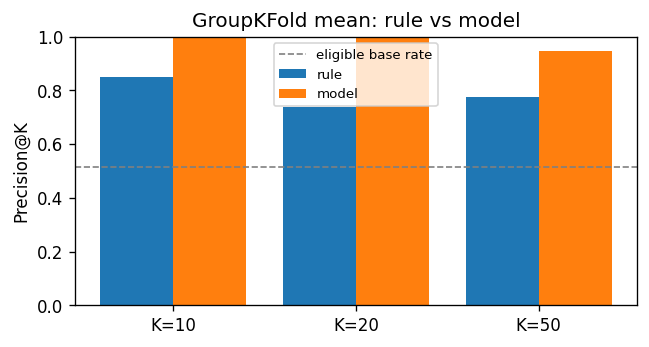

Takeaway: on GroupKFold means, the model beats both the eligible base rate and the past-ctr_gap rule at Precision@10/20/50.


In [4]:
results = methods_mean.reset_index()[
    ["method", "n_folds", "n_test_pages_mean", "base_rate_mean",
     "precision_at_10", "precision_at_20", "precision_at_50"]
]
bench = pd.DataFrame(playbook["benchmarks"])
display(results)
display(bench)

print("\nSafe claim:")
print(claims["safe_claim"])

p_at_k = resolve_fig("w07_precision_at_k.png")
if p_at_k.exists():
    display(Image(filename=str(p_at_k)))
    print(
        "Takeaway: on GroupKFold means, the model beats both the eligible base rate "
        "and the past-ctr_gap rule at Precision@10/20/50."
    )
else:
    print("Missing figure:", p_at_k)

## 5. Limitations

- **Observational only.** No experiment; no causal claim that title/meta edits raise clicks.
- **Proxy label.** Below-tier-median May CTR ≠ “broken page.” Zero-click SERPs and tracking gaps can look like title problems.
- **Past → next, still a proxy.** Mar–Apr features predict a May underperformer flag — useful for ranking reviews, not a guarantee of next-month clicks after an edit.
- **Portfolio-specific tiers.** Tier medians come from this internship portfolio; other sites may need their own baselines.
- **Sparse GA4.** Engagement is missing for many clients; zeros when tracking is off are excluded from meaning.
- **Queue decays.** Mar-only vs Apr-only top-50 overlap was only **0.42** (top-500 **0.23**) — rebuild when the past window shifts; do not treat one queue as permanent.
- **Not Google’s algorithm.** We score pages for reviewer attention; we do not reverse-engineer ranking systems.

Queue stability (Mar-only vs Apr-only past features → same May label):
{
  "top_50_overlap": 0.42,
  "top_500_overlap": 0.23,
  "rank_corr": 0.6797719008125187
}
Note: Mar-only vs Apr-only past features, same May label, GroupKFold OOS scores


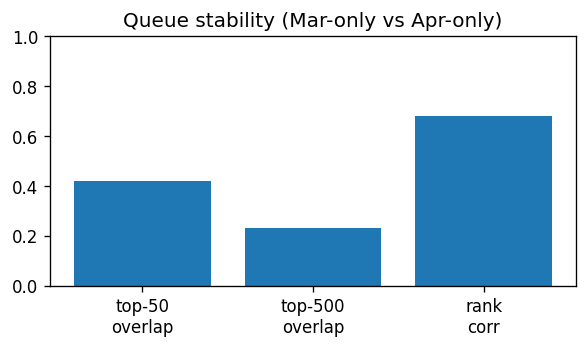

Takeaway: shifting the past window reshuffles the top of the queue — treat rankings as perishable.


In [5]:
print("Queue stability (Mar-only vs Apr-only past features → same May label):")
print(json.dumps(playbook["decay"], indent=2))
print("Note:", playbook.get("decay_note", ""))
stab = resolve_fig("w07_queue_stability.png")
if stab.exists():
    display(Image(filename=str(stab)))
    print("Takeaway: shifting the past window reshuffles the top of the queue — treat rankings as perishable.")
else:
    print("Missing figure:", stab)

## 6. Ranked recommendations

**How an editor should use it.** Rank eligible pages (`imp_prev >= 500`) by the **OOS model score** (Week 5/7 GroupKFold), not by past `ctr_gap`. Attach a reason code → action, then open the top of the list. Before acting: confirm enough past impressions, compare past CTR to the **own-tier** past median, rule out zero-click SERPs, and verify tracking.

**Reason code → action (eligible queue).**  
Buckets are mutually exclusive (fixed if/else order). Shares below are of the **52,001** eligible pages.

| reason_code | Share | Suggested action |
|---|---:|---|
| `high_visibility_ctr_gap` | ~30% | `refresh_and_review_ctr` |
| `zero_click_visible` | ~3% | `check_tracking_first` |
| `deep_tier_ctr_gap` | ~9% | `ranking_not_ctr` (not a CTR fix) |
| `general_ctr_monitor` | ~58% | `monitor` |

**Cost framing (assumption).** ~15 minutes per review. Model top-50 at mean P@50 ≈ 0.945 → ~47 real May underperformers vs ~26 at base rate — fewer wasted opens than scanning at random, with room for false alarms.

**No-go list.** Do not auto-publish rewrites; do not prune/merge without a human; do not act on thin-volume pages; do not treat deep-tier as a CTR fix; do not promise click lifts; do not use past `ctr_gap` / May columns / `trend_*` as model features; do not ship the raw queue as a client audit.

,archetype,pages,action,pct_of_all_pages
0,zero_click_visible,1695,check_tracking_first,3.259553
1,high_visibility_ctr_gap,15757,refresh_and_review_ctr,30.301340
2,deep_tier_ctr_gap,4435,ranking_not_ctr,8.528682
3,general_ctr_monitor,30114,monitor,57.910425


No-go list:
 - auto-publish title/meta rewrites
 - prune / merge / redirect without a human
 - act on thin_volume pages (imp_prev < 500)
 - treat deep_tier as a CTR fix
 - promise a click lift to a client
 - use past ctr_gap / May columns / trend_* as model features
 - send the raw queue to a client as an audit


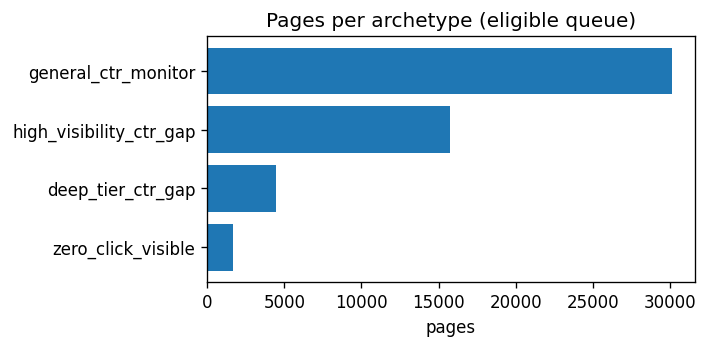

Takeaway: most eligible pages are monitor; spend review time on high_visibility_ctr_gap and zero_click_visible first.


In [6]:
arch = pd.DataFrame(playbook["archetype_mix"])
display(arch[["archetype", "pages", "action", "pct_of_all_pages"]])
print("No-go list:")
for item in playbook["no_go"]:
    print(" -", item)

mix = resolve_fig("w07_archetype_mix.png")
if mix.exists():
    display(Image(filename=str(mix)))
    print(
        "Takeaway: most eligible pages are monitor; spend review time on "
        "high_visibility_ctr_gap and zero_click_visible first."
    )
else:
    print("Missing figure:", mix)

## 7. Artifacts the paper embeds

Receipts and figures the deployed page should show (Week 7 writes PNGs into `work/outputs/`):

| Path | Role |
|---|---|
| `work/outputs/model_vs_baseline_metrics.json` | GroupKFold Precision@K table |
| `work/outputs/playbook_metrics.json` | Archetypes, decay, no-go, paper numbers |
| `work/outputs/baseline_metrics.json` | Eligible-pool baseline |
| `work/outputs/validation_leakage_trap.json` | Honest vs leaky AUC |
| `work/outputs/validation_claim_rewrite.json` | Safe claim wording |
| `work/outputs/w07_precision_at_k.png` | Model vs rule vs base rate |
| `work/outputs/w07_archetype_mix.png` | Action mix |
| `work/outputs/w07_queue_stability.png` | Mar-only vs Apr-only decay |

Upstream notebooks: `w03`–`w07` under `work/notebooks/`. Queue CSV (`action_playbook_queue.csv`) is local/gitignored — regenerate via `w07_action_playbook`.

In [7]:
fig_names = [
    "w07_precision_at_k.png",
    "w07_archetype_mix.png",
    "w07_queue_stability.png",
]
artifact_paths = [
    OUT / "model_vs_baseline_metrics.json",
    OUT / "playbook_metrics.json",
    OUT / "baseline_metrics.json",
    OUT / "validation_leakage_trap.json",
    OUT / "validation_claim_rewrite.json",
] + [resolve_fig(n) for n in fig_names]

def _rel(p: Path) -> str:
    try:
        return str(p.relative_to(ROOT.parent if ROOT.name == "work" else ROOT))
    except ValueError:
        return str(p)

status = pd.DataFrame(
    {"path": [_rel(p) for p in artifact_paths], "exists": [p.exists() for p in artifact_paths]}
)
display(status)
assert status["exists"].all(), "Missing paper artifacts — re-run Weeks 5–7 notebooks first."
print("All paper artifacts present.")

,path,exists
0,work\outputs\model_vs_baseline_metrics.json,True
1,work\outputs\playbook_metrics.json,True
2,work\outputs\baseline_metrics.json,True
3,work\outputs\validation_leakage_trap.json,True
4,work\outputs\validation_claim_rewrite.json,True
5,work\outputs\w07_precision_at_k.png,True
6,work\outputs\w07_archetype_mix.png,True
7,work\outputs\w07_queue_stability.png,True


All paper artifacts present.


## 8. Reproducibility

**Repo.** [rimlazrek1/flyrank-internship](https://github.com/rimlazrek1/flyrank-internship) — notebooks under `work/notebooks/`.

**Upstream notebooks.** `w03_data_contract` → `w04_baseline_score` → `w05_model` → `w06_validation_audit` → `w07_action_playbook` → `capstone`.

**Rerun path.** Install deps from the repo docs; set `HF_TOKEN` in `.env` only if rebuilding warehouse frames. This capstone notebook reads JSON/PNG receipts only (no warehouse pull). Seeds: `random_state=42`. Split: client GroupKFold, `n_splits=4`.

**Public-safe check.** Outputs use hash IDs only — no client names, private URLs, or raw queries. Anyone with the repo can inspect the receipts and re-run the paper notebook.

## 9. Acknowledgments & data credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

Thanks to the FlyRank internship program for the warehouse release, lane framing, and evaluation standards that keep claims public-safe and decision-support honest.